###Kode FLAML dengan BCDF dan BCD
Di bagian 'Remove grade A maupun Grade F'

In [ ]:
!pip install flaml

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 349.7/349.7 kB 24.4 MB/s eta 0:00:00


In [ ]:
!pip uninstall numpy -y
!pip install numpy==1.24.3
!pip install flaml --upgrade

Found existing installation: numpy 2.0.2
Uninstalling numpy-2.0.2:
  Successfully uninstalled numpy-2.0.2
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.3/17.3 MB 46.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
albucore 0.0.24 requires numpy>=1.24.4, but you have numpy 1.24.3 which is incompatible.
albumentations 2.0.8 requires numpy>=1.24.4, but you have numpy 1.24.3 which is incompatible.
blosc2 3.5.1 requires numpy>=1.26, but you have numpy 1.24.3 which is incompatible.
jax 0.5.2 requires numpy>=1.25, but you have numpy 1.24.3 which is incompatible.
jaxlib 0.5.1 requires numpy>=1.25, but you have numpy 1.24.3 which is incompatible.
opencv-python-headless 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.24.3 which is incompatible.
pymc 5.23.0 requires numpy>=1.25.0, but you have numpy 1.24.3 which is inco

In [ ]:
from flaml import AutoML
import flaml
import numpy as np

print("FLAML berhasil diimpor")
print(f"Versi FLAML: {flaml.__version__}")
print(f"Versi NumPy: {np.__version__}")

automl = AutoML()
print("✅ AutoML berhasil diinisialisasi")

FLAML berhasil diimpor
Versi FLAML: 2.6.0
Versi NumPy: 1.24.3
✅ AutoML berhasil diinisialisasi


In [ ]:
from flaml import AutoML
import pandas as pd
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import time

In [ ]:
student_data = pd.read_csv('./Students Performance Dataset.csv')

student_data.drop(columns=['Student_ID', 'First_Name', 'Last_Name', 'Email', 'Total_Score', 'Attendance (%)',
                           'Final_Score', 'Projects_Score'], inplace=True)
student_data.shape

(5000, 15)

In [ ]:
student_data.head()

,Gender,Age,Department,Midterm_Score,Assignments_Avg,Quizzes_Avg,Participation_Score,Grade,Study_Hours_per_Week,Extracurricular_Activities,Internet_Access_at_Home,Parent_Education_Level,Family_Income_Level,Stress_Level (1-10),Sleep_Hours_per_Night
0,Female,22,Mathematics,40.61,73.69,53.17,73.4,F,10.3,Yes,No,Master's,Medium,1,5.9
1,Male,18,Business,57.27,74.23,98.23,88.0,B,27.1,No,No,High School,Low,4,4.3
2,Male,24,Engineering,41.84,85.85,50.00,4.7,D,12.4,Yes,No,High School,Low,9,6.1
3,Female,24,Engineering,45.65,68.10,66.27,4.2,F,25.5,No,Yes,High School,Low,8,4.9
4,Female,23,CS,53.13,67.66,83.98,64.3,C,13.3,Yes,No,Master's,Medium,6,4.5


In [ ]:
student_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 15 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Gender                      5000 non-null   object 
 1   Age                         5000 non-null   int64  
 2   Department                  5000 non-null   object 
 3   Midterm_Score               5000 non-null   float64
 4   Assignments_Avg             5000 non-null   float64
 5   Quizzes_Avg                 5000 non-null   float64
 6   Participation_Score         5000 non-null   float64
 7   Grade                       5000 non-null   object 
 8   Study_Hours_per_Week        5000 non-null   float64
 9   Extracurricular_Activities  5000 non-null   object 
 10  Internet_Access_at_Home     5000 non-null   object 
 11  Parent_Education_Level      3975 non-null   object 
 12  Family_Income_Level         5000 non-null   object 
 13  Stress_Level (1-10)         5000 

###Remove grade A maupun Grade F
Jika ingin menghapus Grade A saja, grade F bisa dikomentar. Jika ingin menghapus grade A dan F, langsung eksekusi dua-duanya

In [ ]:
student_data = student_data[student_data['Grade'] != 'A']
# student_data = student_data[student_data['Grade'] != 'F']

In [ ]:
student_data['Grade'].value_counts()

,count
Grade,
C,2307
D,1760
B,638
F,279


In [ ]:
student_data.describe()

,Age,Midterm_Score,Assignments_Avg,Quizzes_Avg,Participation_Score,Study_Hours_per_Week,Stress_Level (1-10),Sleep_Hours_per_Night
count,4984.000000,4984.000000,4984.000000,4984.000000,4984.000000,4984.000000,4984.000000,4984.000000
mean,21.047753,70.636906,74.908740,74.797145,49.877769,17.517255,5.506421,6.513102
std,1.990981,17.421557,14.394863,14.422735,28.977807,7.196548,2.887127,1.446494
min,18.000000,40.000000,50.000000,50.000000,0.000000,5.000000,1.000000,4.000000
25%,19.000000,55.647500,62.327500,62.337500,25.000000,11.500000,3.000000,5.300000
50%,21.000000,70.730000,75.005000,74.820000,49.400000,17.400000,6.000000,6.500000
75%,23.000000,85.640000,87.230000,87.272500,75.425000,23.700000,8.000000,7.800000
max,24.000000,99.990000,99.990000,99.990000,100.000000,30.000000,10.000000,9.000000


In [ ]:
student_data.isnull().sum()/student_data.shape[0]*100

,0
Gender,0.000000
Age,0.000000
Department,0.000000
Midterm_Score,0.000000
Assignments_Avg,0.000000
Quizzes_Avg,0.000000
Participation_Score,0.000000
Grade,0.000000
Study_Hours_per_Week,0.000000
Extracurricular_Activities,0.000000


In [ ]:
from sklearn.model_selection import train_test_split

X = student_data.drop(columns=['Grade'])
y = student_data['Grade']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size=0.8, random_state=42, stratify=y
)

print("=" * 50)
print("HASIL TRAIN-TEST SPLIT")
print("=" * 50)

print(f"Jumlah data training : {len(X_train)}")
print(f"Jumlah data testing  : {len(X_test)}")

print(f"\nShape X_train : {X_train.shape}")
print(f"Shape X_test  : {X_test.shape}")

print("\nDistribusi Grade pada Dataset Asli")
print(y.value_counts(normalize=True).sort_index())

print("\nDistribusi Grade pada Training Set")
print(y_train.value_counts(normalize=True).sort_index())

print("\nDistribusi Grade pada Testing Set")
print(y_test.value_counts(normalize=True).sort_index())

HASIL TRAIN-TEST SPLIT
Jumlah data training : 3987
Jumlah data testing  : 997

Shape X_train : (3987, 14)
Shape X_test  : (997, 14)

Distribusi Grade pada Dataset Asli
Grade
B    0.128010
C    0.462881
D    0.353130
F    0.055979
Name: proportion, dtype: float64

Distribusi Grade pada Training Set
Grade
B    0.127916
C    0.463005
D    0.353148
F    0.055932
Name: proportion, dtype: float64

Distribusi Grade pada Testing Set
Grade
B    0.128385
C    0.462387
D    0.353059
F    0.056169
Name: proportion, dtype: float64


In [ ]:
import numpy as np
def apply_feature_engineering(data):
    student_data_engineered = data.copy()

    weekly_sleep = (student_data_engineered['Sleep_Hours_per_Night'] * 7)
    student_data_engineered['Study_Sleep_Ratio'] = student_data_engineered['Study_Hours_per_Week'] / (weekly_sleep + 0.1)

    income_weights = {'Low': 1, 'Medium': 2, 'High': 3}
    edu_weights = {'High School': 1, "Bachelor's": 2, "Master's": 3, 'PhD': 4, 'Unknown': 0}


    income_score = student_data_engineered['Family_Income_Level'].map(income_weights).fillna(0)
    edu_score = student_data_engineered['Parent_Education_Level'].map(edu_weights).fillna(0)

    student_data_engineered['SES_Score'] = income_score + edu_score

    extra_hours = np.where(student_data_engineered['Extracurricular_Activities'] == 'Yes', 10, 0)

    student_data_engineered['Total_Weekly_Load'] = student_data_engineered['Study_Hours_per_Week'] + extra_hours

    student_data_engineered['Load_Sleep_Ratio'] = student_data_engineered['Total_Weekly_Load'] / (weekly_sleep + 0.1)

    return student_data_engineered

X_train_fe = apply_feature_engineering(X_train)
X_test_fe = apply_feature_engineering(X_test)

In [ ]:
from imblearn.over_sampling import RandomOverSampler

ros = RandomOverSampler(random_state=42)

X_train_ros, y_train_ros = ros.fit_resample(
    X_train_fe, y_train
)

print("Distribusi kelas sebelum oversampling:")
print(y_train.value_counts())

print("\nDistribusi kelas setelah Random Oversampling:")
print(y_train_ros.value_counts())

Distribusi kelas sebelum oversampling:
Grade
C    1846
D    1408
B     510
F     223
Name: count, dtype: int64

Distribusi kelas setelah Random Oversampling:
Grade
B    1846
D    1846
C    1846
F    1846
Name: count, dtype: int64


###Konfigurasi FLAML dengan kelas F

In [ ]:
#konfigurasi automl
import pickle
from sklearn.metrics import balanced_accuracy_score


automl = AutoML()

settings = {
    'time_budget': 900,              # 15 menit
    'metric': 'macro_f1',
    'task': 'classification',
    'log_file_name': 'flaml_raw.log',
    'seed': 42,
    'n_jobs': -1,
    'eval_method': 'cv',
    'n_splits': 3,
    'verbose': True,
    'early_stop': True,

}

print("Lagi training FLAML")

start_time = time.time()
automl.fit(X_train_ros, y_train_ros, **settings)
end_time = time.time()


print(f"\nWaktu training: {end_time - start_time:.2f} detik")
print(f"Best model: {automl.best_estimator}")
print(f"Best F1-Macro (CV): {automl.best_loss:.4f}")
print(f"Best model configuration: {automl.best_config}")


print("\n=== EVALUASI DENGAN TEST SET (MENTAH) ===")

#otomatis preprocessing test set juga
y_pred_flaml = automl.predict(X_test_fe)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_flaml,
                            target_names=['B', 'C', 'D', 'F']))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_flaml))

print(f"\nMacro F1-Score: {f1_score(y_test, y_pred_flaml, average='macro'):.4f}")
print(f"Weighted F1-Score: {f1_score(y_test, y_pred_flaml, average='weighted'):.4f}")
bal_acc = balanced_accuracy_score(y_test, y_pred_flaml)
print(f"Balanced Accuracy: {bal_acc:.4f}")

#Save best model
model_path = 'flaml_best_model.pkl'
with open(model_path, 'wb') as f:
    pickle.dump(automl, f)
print(f"\nFLAML model saved to {model_path}")

Lagi training FLAML


INFO:flaml.tune.searcher.blendsearch:No low-cost partial config given to the search algorithm. For cost-frugal search, consider providing low-cost values for cost-related hps via 'low_cost_partial_config'. More info can be found at https://microsoft.github.io/FLAML/docs/FAQ#about-low_cost_partial_config-in-tune
INFO:flaml.tune.searcher.blendsearch:No low-cost partial config given to the search algorithm. For cost-frugal search, consider providing low-cost values for cost-related hps via 'low_cost_partial_config'. More info can be found at https://microsoft.github.io/FLAML/docs/FAQ#about-low_cost_partial_config-in-tune



Waktu training: 924.40 detik
Best model: extra_tree
Best F1-Macro (CV): 0.1820
Best model configuration: {'n_estimators': 2047, 'max_features': 0.2827108741224507, 'max_leaves': 3691, 'criterion': 'entropy'}

=== EVALUASI DENGAN TEST SET (MENTAH) ===

Classification Report:
              precision    recall  f1-score   support

           B       0.00      0.00      0.00       128
           C       0.51      0.78      0.62       461
           D       0.50      0.42      0.46       352
           F       0.00      0.00      0.00        56

    accuracy                           0.51       997
   macro avg       0.25      0.30      0.27       997
weighted avg       0.41      0.51      0.45       997


Confusion Matrix:
[[  0 121   7   0]
 [  1 358 102   0]
 [  0 204 148   0]
 [  0  19  37   0]]

Macro F1-Score: 0.2685
Weighted F1-Score: 0.4464
Balanced Accuracy: 0.2993


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



FLAML model saved to flaml_best_model.pkl


###Konfigurasi FLAML tanpa kelas F

In [ ]:
#konfigurasi automl
import pickle
from sklearn.metrics import balanced_accuracy_score


automl = AutoML()

settings = {
    'time_budget': 900,              # 15 menit
    'metric': 'macro_f1',
    'task': 'classification',
    'log_file_name': 'flaml_raw.log',
    'seed': 42,
    'n_jobs': -1,
    'eval_method': 'cv',
    'n_splits': 3,
    'verbose': True,
    'early_stop': True,

}

print("Lagi training FLAML")

start_time = time.time()
automl.fit(X_train_ros, y_train_ros, **settings)
end_time = time.time()


print(f"\nWaktu training: {end_time - start_time:.2f} detik")
print(f"Best model: {automl.best_estimator}")
print(f"Best F1-Macro (CV): {automl.best_loss:.4f}")
print(f"Best model configuration: {automl.best_config}")


print("\n=== EVALUASI DENGAN TEST SET (MENTAH) ===")

#otomatis preprocessing test set juga
y_pred_flaml = automl.predict(X_test_fe)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_flaml,
                            target_names=['B', 'C', 'D']))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_flaml))

print(f"\nMacro F1-Score: {f1_score(y_test, y_pred_flaml, average='macro'):.4f}")
print(f"Weighted F1-Score: {f1_score(y_test, y_pred_flaml, average='weighted'):.4f}")
bal_acc = balanced_accuracy_score(y_test, y_pred_flaml)
print(f"Balanced Accuracy: {bal_acc:.4f}")

#Save best model
model_path = 'flaml_best_model.pkl'
with open(model_path, 'wb') as f:
    pickle.dump(automl, f)
print(f"\nFLAML model saved to {model_path}")

Lagi training FLAML


INFO:flaml.tune.searcher.blendsearch:No low-cost partial config given to the search algorithm. For cost-frugal search, consider providing low-cost values for cost-related hps via 'low_cost_partial_config'. More info can be found at https://microsoft.github.io/FLAML/docs/FAQ#about-low_cost_partial_config-in-tune
INFO:flaml.tune.searcher.blendsearch:No low-cost partial config given to the search algorithm. For cost-frugal search, consider providing low-cost values for cost-related hps via 'low_cost_partial_config'. More info can be found at https://microsoft.github.io/FLAML/docs/FAQ#about-low_cost_partial_config-in-tune



Waktu training: 906.97 detik
Best model: extra_tree
Best F1-Macro (CV): 0.2421
Best model configuration: {'n_estimators': 723, 'max_features': 0.45927009466896707, 'max_leaves': 1468, 'criterion': 'gini'}

=== EVALUASI DENGAN TEST SET (MENTAH) ===

Classification Report:
              precision    recall  f1-score   support

           B       0.27      0.03      0.06       128
           C       0.52      0.72      0.60       461
           D       0.55      0.46      0.50       352

    accuracy                           0.53       941
   macro avg       0.45      0.40      0.39       941
weighted avg       0.50      0.53      0.49       941


Confusion Matrix:
[[  4 114  10]
 [ 10 331 120]
 [  1 190 161]]

Macro F1-Score: 0.3869
Weighted F1-Score: 0.4908
Balanced Accuracy: 0.4022

FLAML model saved to flaml_best_model.pkl


### Visualisasi Confusion Matrix dan Feature Importance
BIsa diganti class Labelnya jika tidak menggunakan kelas F.

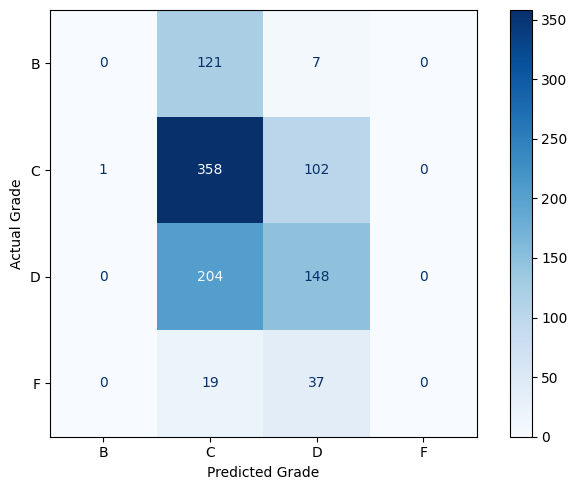

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

class_labels = ['B', 'C', 'D', 'F']

cm = confusion_matrix(y_test, y_pred_flaml)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)

fig, ax = plt.subplots(figsize=(7, 5))
disp.plot(cmap='Blues', ax=ax, values_format='d')

ax.set_xlabel('Predicted Grade')
ax.set_ylabel('Actual Grade')


plt.tight_layout()
plt.savefig('confusion_matrix_flaml_no_f.pdf')
plt.show()


=== ANALISIS FEATURE IMPORTANCE ===

Ranking Fitur Paling Berpengaruh Terhadap GRADE:
                     Fitur  Tingkat Kepentingan
      Study_Hours_per_Week             0.127307
Extracurricular_Activities             0.108806
   Internet_Access_at_Home             0.082008
    Parent_Education_Level             0.069688
       Stress_Level (1-10)             0.052610
       Participation_Score             0.052466
     Sleep_Hours_per_Night             0.051867
       Family_Income_Level             0.048088
                       Age             0.047876
         Total_Weekly_Load             0.047136
                 SES_Score             0.046121
           Assignments_Avg             0.045777
         Study_Sleep_Ratio             0.045764
          Load_Sleep_Ratio             0.045001
               Quizzes_Avg             0.041891
                    Gender             0.032551
             Midterm_Score             0.031645
                Department             0.023398


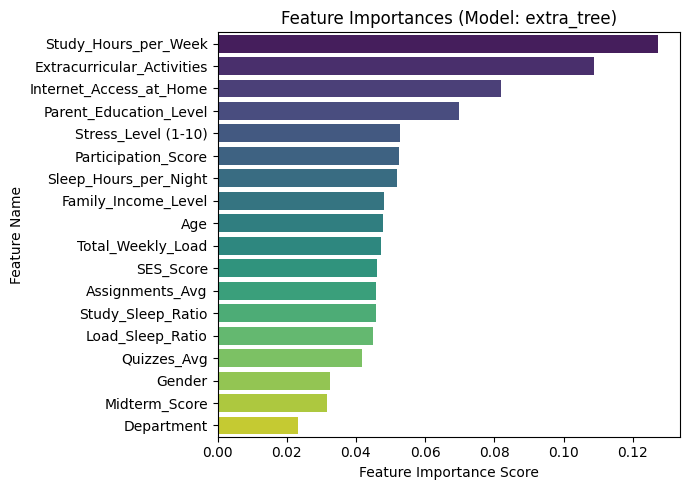

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("\n=== ANALISIS FEATURE IMPORTANCE ===")

best_estimator = automl.model.estimator

if hasattr(best_estimator, 'feature_importances_'):

    importances = best_estimator.feature_importances_

    if hasattr(X_train_fe, 'columns'):
        feature_names = X_train_fe.columns
    else:
        feature_names = [f"Feature_{i}" for i in range(len(importances))]

    df_importance = pd.DataFrame({
        'Fitur': feature_names,
        'Tingkat Kepentingan': importances
    })

    df_importance = df_importance.sort_values(by='Tingkat Kepentingan', ascending=False)

    print("\nRanking Fitur Paling Berpengaruh Terhadap GRADE:")
    print(df_importance.to_string(index=False))

    plt.figure(figsize=(7, 5))
    sns.barplot(
        data=df_importance,
        x='Tingkat Kepentingan',
        y='Fitur',
        palette='viridis',
        hue='Fitur',
        legend=False
    )
    plt.title(f'Feature Importances (Model: {automl.best_estimator})')
    plt.xlabel('Feature Importance Score')
    plt.ylabel('Feature Name')
    plt.tight_layout()
    plt.show()

else:
    print(f"\nModel terbaik yang terpilih ({automl.best_estimator}) tidak mendukung ekstraksi feature_importances_ secara langsung.")